In [2]:
with open('names.txt', 'r') as file:
    names = file.read().splitlines()

names = [name.lower() for name in names]

In [3]:
chars = sorted(list(set(''.join(names))))

stoi = { ch:i+1 for i,ch in enumerate(chars) }
stoi['$'] = 0
itos = { i:ch for ch,i in stoi.items() }
vocab_size = len(stoi)
vocab_size


30

In [4]:
block_size = 3

In [1]:
import flashlight

def get_dataset(names):
  X = []
  Y = []
  for name in names:
      context = [0]*block_size
      for ch  in name + '$':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
  X = flashlight.Tensor(X)
  Y = flashlight.Tensor(Y)
  return X,Y

In [ ]:
def view_input_output(X, Y):
  for (context, output) in zip(X, Y):
    context_sequence = [itos[x] for x in context]
    out = itos[output]

In [ ]:
import random
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

X_train, Y_train = get_dataset(names[:n1])
X_dev, Y_dev = get_dataset(names[n1:n2])
X_test, Y_test = get_dataset(names[n2:])

view_input_output(X_test[:2].numpy(), Y_test[:2].numpy())

In [ ]:
X_train.shape, Y_train.shape

((405075, 3), (405075,))

In [ ]:
embedding_size = 10
hidden_layers = 200

In [ ]:
g = flashlight.Generator().manual_seed(2147483647)

In [ ]:
C = flashlight.randn((vocab_size, embedding_size), generator=g)
W1 = flashlight.randn((embedding_size * block_size, hidden_layers), generator=g)

W2 = flashlight.randn(hidden_layers, vocab_size, generator=g)
B2 = flashlight.randn(vocab_size, generator=g)

bngain = flashlight.ones(1, hidden_layers)
bnbias = flashlight.zeros(1, hidden_layers)

In [ ]:
W1.shape

(30, 200)

In [ ]:
parameters = [C, W1, W2, B2, bngain, bnbias]
for p in parameters:
  p.requires_grad = True

In [ ]:
number_of_parameters = sum(p.nelement() for p in parameters)
number_of_parameters

12730

In [ ]:
X_train.shape, C.shape

((405075, 3), (30, 10))

In [ ]:
def forward_pass(X, Y, bnmean_running, bnstd_running):
  emb = C[X]
  embcat = emb.view(emb.shape[0], -1)
  pass_through_hidden = embcat @ W1
  mean_hidden = pass_through_hidden.mean(0, keepdim=True)
  std_hidden = pass_through_hidden.std(0, keepdim=True)

  with flashlight.no_grad():
    bnmean_running = bnmean_running * 0.999 + mean_hidden * 0.001
    bnstd_running = bnstd_running * 0.999 + std_hidden * 0.001

  normalized = (pass_through_hidden - mean_hidden)/std_hidden
  apply_batch_nomalisation = bngain * normalized + bnbias
  non_linearity = flashlight.tanh(apply_batch_nomalisation)
  logits = non_linearity @ W2 + B2
  output_probs = flashlight.softmax(logits, dim=1)
  indices = flashlight.arange(output_probs.shape[0])
  likelihood = output_probs[indices, Y]
  log_likelihood = flashlight.log(likelihood)
  loss = -log_likelihood.mean()
  return {
    "loss": loss,
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [ ]:
def forward_pass_batch(X, Y, bnmean_running, bnstd_running, batch_size=32):
  random_batch_indices = flashlight.randint(0, X_train.shape[0], (batch_size,), generator=g)
  X_batch = X[random_batch_indices]
  Y_batch = Y[random_batch_indices]
  result = forward_pass(X_batch, Y_batch, bnmean_running, bnstd_running)
  return result

In [ ]:
def train(X, Y, epochs=50000, log_interval=1000, lr=0.01):
  bnmean_running = flashlight.zeros(1, hidden_layers)
  bnstd_running = flashlight.ones(1, hidden_layers)
  losses = []
  for epoch in range(epochs):
    result = forward_pass_batch(X, Y, bnmean_running, bnstd_running)
    batch_loss = result["loss"]
    bnmean_running = result["bnmean_running"]
    bnstd_running = result["bnstd_running"]
    losses.append((epoch, batch_loss.item()))

    for p in parameters:
      p.grad = None
    result["loss"].backward()

    for p in parameters:
      if p.grad is not None:
        p.data += -lr * p.grad.data
    if epoch % log_interval == 0:
      print(f"Epoch: {epoch}: Loss: {result['loss']}")
  final_loss = losses[epochs - 1]  
  return {
    "losses": losses,
    "final_loss": final_loss[1],
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [ ]:
import importlib
importlib.reload(flashlight)

result = train(X_train, Y_train)
losses = result["losses"]
final_loss = result["final_loss"]
bnmean_running = result["bnmean_running"]
bnstd_running = result["bnstd_running"]
print('Final loss', final_loss)

Epoch: 0: Loss: Tensor(data=16.797054290771484, shape=(), requires_grad=True)
Epoch: 1000: Loss: Tensor(data=3.681013584136963, shape=(), requires_grad=True)
Epoch: 2000: Loss: Tensor(data=2.5190062522888184, shape=(), requires_grad=True)
Epoch: 3000: Loss: Tensor(data=2.704411268234253, shape=(), requires_grad=True)
Epoch: 4000: Loss: Tensor(data=3.4761056900024414, shape=(), requires_grad=True)
Epoch: 5000: Loss: Tensor(data=2.5213701725006104, shape=(), requires_grad=True)
Epoch: 6000: Loss: Tensor(data=2.5359315872192383, shape=(), requires_grad=True)
Epoch: 7000: Loss: Tensor(data=2.58638596534729, shape=(), requires_grad=True)
Epoch: 8000: Loss: Tensor(data=2.593613386154175, shape=(), requires_grad=True)
Epoch: 9000: Loss: Tensor(data=2.4493961334228516, shape=(), requires_grad=True)
Epoch: 10000: Loss: Tensor(data=2.272571325302124, shape=(), requires_grad=True)
Epoch: 11000: Loss: Tensor(data=2.1751179695129395, shape=(), requires_grad=True)
Epoch: 12000: Loss: Tensor(data=2.3

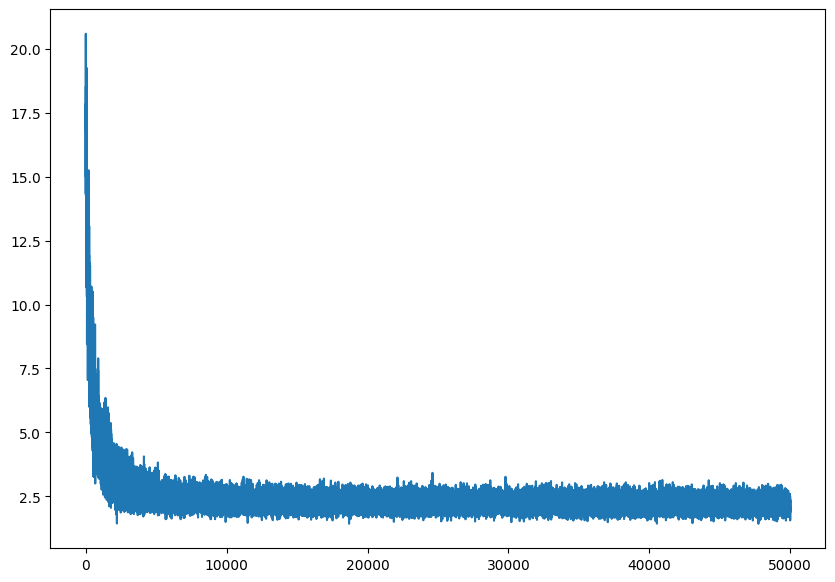

In [ ]:
# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot([x for x, _ in losses], [y for _, y in losses])
plt.show()

In [ ]:
def validate(X, Y, bnmean_running, bnstd_running):
  emb = C[X]
  embcat = emb.view(emb.shape[0], -1)
  pass_through_hidden = embcat @ W1
  mean_hidden = pass_through_hidden.mean(0, keepdim=True)
  std_hidden = pass_through_hidden.std(0, keepdim=True)
  batch_normalisation = bngain * (pass_through_hidden - mean_hidden)/std_hidden + bnbias
  non_linearity = flashlight.tanh(batch_normalisation)
  logits = non_linearity @ W2 + B2
  output_probs = flashlight.softmax(logits, dim=1)
  indices = flashlight.arange(output_probs.shape[0])
  likelihood = output_probs[indices, Y]
  log_likelihood = flashlight.log(likelihood)
  loss = -log_likelihood.mean()
  return loss

In [ ]:
test_loss = validate(X_test, Y_test, bnmean_running, bnstd_running)
print('Test loss', test_loss)

Test loss Tensor(data=2.1605420112609863, shape=(), requires_grad=True)


In [ ]:
validation_loss = validate(X_dev, Y_dev, bnmean_running, bnstd_running)
print('Validation loss', validation_loss)

Validation loss Tensor(data=2.1531107425689697, shape=(), requires_grad=True)


In [ ]:
# Generate 200 names using the trained model above

names = []
for _ in range(200):
    out = []
    context = [0] * block_size
    while True:
        emb = C[flashlight.Tensor([context])]
        embcat = emb.view(1, -1)
        pass_through_hidden = embcat @ W1
        normalized = (pass_through_hidden - bnmean_running) / bnstd_running
        apply_batch_norm = bngain * normalized + bnbias
        h = flashlight.tanh(apply_batch_norm)
        logits = h @ W2 + B2
        probs = flashlight.softmax(logits, dim=1)
        ix = flashlight.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        out.append(itos[ix])
        context = context[1:] + [ix]
    names.append(''.join(out))

for name in names:
    print(name)



dhi
dovehathxy
tha
diav
anon
rara
muzeka
keesuma
vitha
sandhaisthahan
tha
thmi
ina
jasharin
gee
juvashan
yasheupanan
sushitheyalvea
raji
keekan
borujelriyahha
ni nrajiliko
neethewakanalishadirpshithiha
rajajshakrasha
nyan
giva
san
gajanya
jaa
jaritwi
vi
radha
cha
kiithanalathra
musha
mahoyanjeenisunthha
kela
manunanidhana
gana
janwhaai
ham
havi
srledan
kavhak
ary
laxthavithan
voitha
mamavant
keralana
jilandhak
bhurkhavindithan
eesila
kuvaikushavlan
ari
reyunah
vaka
kien
vim
gan
jara
rva
ayaapri
kirla
hiarhi
dudaysha
vandhana
arithavisbaruhanan
usan
man
oninchiltudha
ikramay
havan
angadhesarni
arujekeen
sharsha
nikashila
pusina
omananhathea
pamaheshanupshratarah
dara
kuvenithikra
aahirajin
thav
viltulath
tha
rodinyamin
jiman
jelara
thethishi
rim
atha
pushan
haaraha
bhayan
saakisriga
man
arta
rashrath
man
ganari
vaka
cyakrithye
karshan
atheelthitharhheeya
gavga
gar
ashayagar
ndhil
tanarin
dauran
agi
vantha
dan
rugaganulle
ashmalita
ajuruja
abhaana
thukshanindaksh
bhavanni
mal
kirmaa
shan